<a href="https://colab.research.google.com/github/katsuhiro-wq/katsuhiro-wq/blob/sub1/%E3%82%B7%E3%83%A3%E3%83%B3%E3%83%88%E9%9F%B3%E8%A7%A3%E6%9E%90%E3%82%B5%E3%83%B3%E3%83%97%E3%83%AB%E3%82%B3%E3%83%BC%E3%83%89_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# サンプルデータ一つ

In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, iirnotch
import soundfile as sf
import csv

In [2]:
# === シャント音の録音ファイルを読み込む（10秒間録音） ===
filename = 'audio.wav'  # 音声ファイルのパス
# librosa.loadで音声ファイルを読み込み、波形データ y とサンプリングレート sr を取得
y, sr = librosa.load(filename)  # duration=10をつけると最初の10秒間のみ読み込む

In [3]:
# === バンドパスフィルタの設計 ===
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs  # ナイキスト周波数を計算
    low = lowcut / nyq  # 正規化した低周波数（0〜1の範囲）
    high = highcut / nyq  # 正規化した高周波数（0〜1の範囲）
    b, a = butter(order, [low, high], btype='band')  # バンドパスフィルタの係数を計算
    return b, a

In [4]:
# === ノッチフィルタの設計と適用 ===
def apply_notch_filter(signal, freq, fs, quality_factor=30):
    # ノッチ周波数を正規化（0〜1の範囲）
    w0 = freq / (fs / 2)
    # ノッチフィルタの係数を計算
    b, a = iirnotch(w0, quality_factor)
    # フィルタを適用してノッチング
    y_notched = lfilter(b, a, signal)
    return y_notched

filtered_shunt_sound.wav を保存しました。


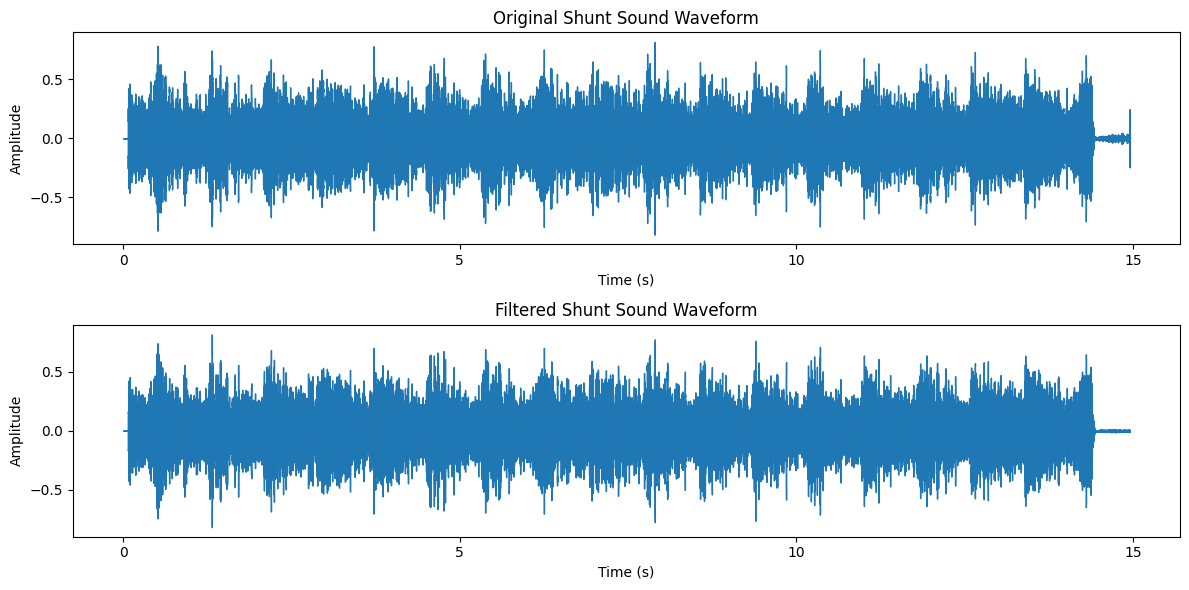

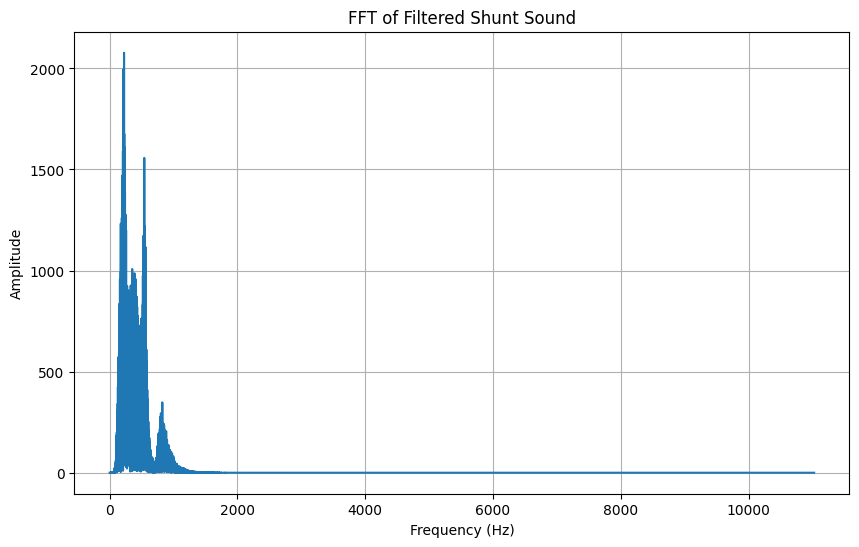

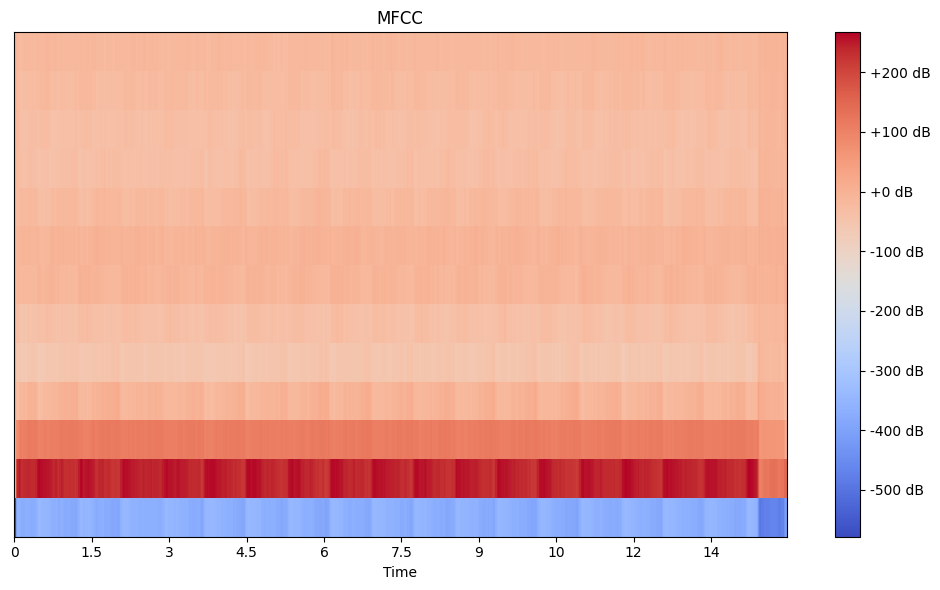

Peak Frequency: 225.70 Hz
MFCC Mean Coefficients: [-370.13962301  238.08346649  109.46198243   -5.47696604  -50.31686607
  -34.90865071   -7.95693201   -3.8410863   -19.19885442  -32.17027514
  -31.41566982  -22.86970665  -16.07678616]


In [6]:
# === フィルタリングの適用 ===
# フィルタのパラメータ設定
lowcut = 100.0  # 低周波数カットオフ（Hz）
highcut = 1000.0  # 高周波数カットオフ（Hz）

# バンドパスフィルタを設計し、信号に適用
b, a = butter_bandpass(lowcut, highcut, sr, order=5)
y_filtered = lfilter(b, a, y)

# ノッチフィルタの適用（例として50Hzを除去）
notch_freq = 50.0  # ノッチフィルタの周波数（Hz）
y_filtered = apply_notch_filter(y_filtered, notch_freq, sr)

# === フィルタ処理後の波形をWAV形式で保存 ===
output_filename = "filtered_shunt_sound.wav"  # 出力ファイル名
sf.write(output_filename, y_filtered, sr)  # 波形データをWAVファイルとして保存

print(f"{output_filename} を保存しました。")

# === フィルタ前後の波形をプロット ===
plt.figure(figsize=(12, 6))

# オリジナルの波形をプロットするために、yをy_originalに代入
y_original = y

# オリジナルの波形
plt.subplot(2, 1, 1)
librosa.display.waveshow(y_original, sr=sr)
plt.title("Original Shunt Sound Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# フィルタ後の波形
plt.subplot(2, 1, 2)
librosa.display.waveshow(y_filtered, sr=sr)
plt.title("Filtered Shunt Sound Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# === FFT（フーリエ変換）による周波数解析 ===
fft_result = np.fft.fft(y_filtered)  # フーリエ変換を実行
fft_freqs = np.fft.fftfreq(len(fft_result), d=1/sr)  # 周波数軸を計算

# 振幅スペクトルをプロット（正の周波数成分のみ）
plt.figure(figsize=(10, 6))
plt.plot(fft_freqs[:len(fft_freqs)//2], np.abs(fft_result[:len(fft_result)//2]))
plt.title("FFT of Filtered Shunt Sound")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# === MFCC（メル周波数ケプストラム係数）の計算 ===
mfccs = librosa.feature.mfcc(y=y_filtered, sr=sr, n_mfcc=13)  # 13次のMFCCを計算

# MFCCをプロット
plt.figure(figsize=(10, 6))
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('MFCC')
plt.tight_layout()
plt.show()

# === 特徴量の抽出（MFCCの係数やFFTのピークなど） ===
# ピーク周波数を計算（振幅が最大の周波数）
peak_idx = np.argmax(np.abs(fft_result[:len(fft_result)//2]))  # 正の周波数成分のみを考慮
peak_frequency = fft_freqs[peak_idx]

# MFCCの平均値を計算（各係数ごと）
mfcc_mean = np.mean(mfccs, axis=1)

with open('features.csv', 'w', newline='') as csvfile:
       writer = csv.writer(csvfile)
       writer.writerow(['peak_frequency'] + [f'mfcc_{i}' for i in range(13)])  # ヘッダー行
       writer.writerow([peak_frequency] + list(mfcc_mean))  # 特徴量データ

print(f"Peak Frequency: {peak_frequency:.2f} Hz")
print(f"MFCC Mean Coefficients: {mfcc_mean}")


以下は恣意的にカットオフを決める場合

In [7]:

# === 判定部分の例（シャント不全と比較する処理） ===
threshold_frequency = 200  # シャント不全の周波数基準（Hz）（例）
frequency_tolerance = 20  # 許容範囲（Hz）

# ピーク周波数と基準値を比較して判定
if abs(peak_frequency - threshold_frequency) < frequency_tolerance:
    print("シャント不全の可能性あり")
else:
    print("正常なシャント音")

正常なシャント音


# シミュレーション

In [8]:
import librosa
import numpy as np
import os
import soundfile as sf

# === オリジナルのシャント音録音ファイルを読み込む（10秒間録音） ===
filename = 'audio.wav'  # オリジナル音声ファイルのパス
# librosa.loadで音声ファイルを読み込み、波形データ y_original とサンプリングレート sr を取得
y_original, sr = librosa.load(filename, duration=10)  # duration=10 で最初の10秒間のみを読み込む

# === シミュレーションで似たようなファイルを50個作成 ===

# 出力ディレクトリの設定
output_dir = 'simulated_shunt_sounds'  # シミュレーション音声の保存先ディレクトリ
if not os.path.exists(output_dir):
    os.makedirs(output_dir)  # ディレクトリが存在しない場合は作成

# シミュレーションのパラメータ範囲の設定
noise_levels = np.linspace(0.001, 0.01, 50)  # ノイズレベルの範囲（50段階）
pitch_shift_steps = np.linspace(-2, 2, 50)  # ピッチシフトの範囲（半音単位、50段階）
time_stretch_rates = np.linspace(0.9, 1.1, 50)  # タイムストレッチの範囲（50段階）

# 乱数シードの設定（結果の再現性のため）
np.random.seed(42)

for i in range(50):
    y_simulated = y_original.copy()  # オリジナル音声をコピー

    # === ランダムなノイズを追加 ===
    noise_level = np.random.choice(noise_levels)  # ノイズレベルをランダムに選択
    noise = noise_level * np.random.randn(len(y_simulated))  # ガウスノイズを生成
    y_simulated += noise  # ノイズを音声に追加

    # === ランダムなピッチシフトを適用 ===
    n_steps = np.random.choice(pitch_shift_steps)  # ピッチシフト量をランダムに選択
    # pitch_shift の呼び出しを更新し、必要なパラメータをキーワード引数で渡す
    y_simulated = librosa.effects.pitch_shift(y=y_simulated, sr=sr, n_steps=n_steps)

    # === ランダムなタイムストレッチを適用 ===
    rate = np.random.choice(time_stretch_rates)  # タイムストレッチ率をランダムに選択
    # time_stretch() now expects a dictionary as input
    y_simulated = librosa.effects.time_stretch(y=y_simulated, rate=rate)

    # === シミュレーション音声をファイルに保存 ===
    output_filename = f'simulated_shunt_{i+1:02d}.wav'  # 出力ファイル名を連番で作成
    output_path = os.path.join(output_dir, output_filename)
    sf.write(output_path, y_simulated, sr)  # 音声ファイルを保存

    #print(f"{output_filename} を生成しました。")  # 進行状況を表示

In [9]:
import os
import csv
import random
import librosa
import numpy as np
import pandas as pd

# === ラベル作成処理 ===
output_dir = 'simulated_shunt_sounds'  # シミュレーション音声の保存先ディレクトリ
threshold_frequency = 200  # シャント不全の周波数基準（Hz）（例）
frequency_tolerance = 20  # 許容範囲（Hz）

# ラベルを保存するCSVファイルを開く
with open('ground_truth_labels.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['filename', 'label'])  # ヘッダー行を書き込む

    for filename in os.listdir(output_dir):
        if filename.endswith('.wav'):
            filepath = os.path.join(output_dir, filename)
            y, sr = librosa.load(filepath)

            # FFT（フーリエ変換）による周波数解析
            fft_result = np.fft.fft(y)  # フーリエ変換を実行
            fft_freqs = np.fft.fftfreq(len(fft_result), d=1 / sr)  # 周波数軸を計算

            # ピーク周波数を計算（振幅が最大の周波数）
            peak_idx = np.argmax(np.abs(fft_result[:len(fft_result) // 2]))  # 正の周波数成分のみを考慮
            peak_frequency = fft_freqs[peak_idx]

            # ピーク周波数と基準値を比較してラベルを決定
            if abs(peak_frequency - threshold_frequency) < frequency_tolerance:
                label = 'true'  # シャント不全の可能性あり
            else:
                label = 'false'  # 正常なシャント音

            # ファイル名とラベルをCSVファイルに書き込む
            writer.writerow([filename, label])

print("ground_truth_labels.csv が作成されました。")

# === 感度と特異度の計算 ===
# 予測ラベルを読み込む (predicted labels) - ここではground_truthと同じものを使用
predicted_labels = {}
with open('ground_truth_labels.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)  # ヘッダー行をスキップ
    for row in reader:
        predicted_labels[row[0]] = row[1]

# 真陽性 (TP)、偽陽性 (FP)、真陰性 (TN)、偽陰性 (FN) をカウント
TP = FP = TN = FN = 0
for filename in predicted_labels:
    ground_truth = predicted_labels[filename] # ground_truthとpredicted_labelsは同じ
    predicted = predicted_labels[filename]

    if ground_truth == 'true' and predicted == 'true':
        TP += 1
    elif ground_truth == 'false' and predicted == 'true':
        FP += 1
    elif ground_truth == 'false' and predicted == 'false':
        TN += 1
    elif ground_truth == 'true' and predicted == 'false':
        FN += 1

# 感度 (Sensitivity) と特異度 (Specificity) を計算
sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0  # ゼロ除算を回避
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0  # ゼロ除算を回避

print(f"感度 (Sensitivity): {sensitivity:.2f}")
print(f"特異度 (Specificity): {specificity:.2f}")

# Create a DataFrame 'df' with original data and predictions
# You'll need to replace this with your actual data and predictions
data = []
for filename in predicted_labels:
    ground_truth = predicted_labels[filename]  # ground_truth and predicted_labels are the same
    predicted = predicted_labels[filename]
    # Add any other relevant data you want to include in the DataFrame
    data.append([filename, ground_truth, predicted])  # Example: filename, ground truth, prediction

df = pd.DataFrame(data, columns=['filename', 'ground_truth', 'prediction'])

# Displaying results using pandas' display function
results = {'Sensitivity': [sensitivity], 'Specificity': [specificity]}
print("Sensitivity and Specificity Results:")
display(pd.DataFrame(results, index=[0]))  # Use display instead of ace_tools

# Assuming you have a pandas DataFrame named 'df' with original data and predictions
print("\nOriginal Data with Predictions:")
display(df)  # Use display instead of ace_tools

ground_truth_labels.csv が作成されました。
感度 (Sensitivity): 1.00
特異度 (Specificity): 1.00
Sensitivity and Specificity Results:


,Sensitivity,Specificity
0,1.0,1.0



Original Data with Predictions:


,filename,ground_truth,prediction
0,simulated_shunt_26.wav,false,false
1,simulated_shunt_49.wav,false,false
2,simulated_shunt_32.wav,false,false
3,simulated_shunt_42.wav,true,true
4,simulated_shunt_43.wav,true,true
5,simulated_shunt_17.wav,false,false
6,simulated_shunt_29.wav,true,true
7,simulated_shunt_03.wav,false,false
8,simulated_shunt_15.wav,false,false
9,simulated_shunt_21.wav,false,false


In [10]:
# === 特徴量抽出と機械学習による分類 ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import librosa.feature

def extract_features(audio_path):
    """音声ファイルから特徴量を抽出する関数"""
    # 音声データの読み込み
    y, sr = librosa.load(audio_path)

    # 各種特徴量の抽出
    # MFCCs (メル周波数ケプストラム係数)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs, axis=1)

    # スペクトル重心
    spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_centroids_mean = np.mean(spectral_centroids)

    # スペクトルロールオフ
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    spectral_rolloff_mean = np.mean(spectral_rolloff)

    # ゼロ交差率
    zero_crossing = librosa.feature.zero_crossing_rate(y)
    zero_crossing_mean = np.mean(zero_crossing)

    # 特徴量の結合
    features = np.concatenate([
        mfccs_mean,
        [spectral_centroids_mean],
        [spectral_rolloff_mean],
        [zero_crossing_mean]
    ])

    return features

# 全音声ファイルの特徴量を抽出
X = []  # 特徴量を格納するリスト
y = []  # ラベルを格納するリスト
filenames = []  # ファイル名を格納するリスト

for filename in os.listdir(output_dir):
    if filename.endswith('.wav'):
        filepath = os.path.join(output_dir, filename)
        # 特徴量の抽出
        features = extract_features(filepath)
        X.append(features)

        # ラベルの取得
        label = predicted_labels[filename]  # 'true' または 'false'
        y.append(1 if label == 'true' else 0)

        filenames.append(filename)

# リストをNumPy配列に変換
X = np.array(X)
y = np.array(y)

# データの分割（学習用と検証用）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 特徴量の正規化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ランダムフォレスト分類器の学習
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# 予測と評価
y_pred = clf.predict(X_test_scaled)

# 分類結果のレポート出力
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))

# 混同行列の出力
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 特徴量の重要度を表示
feature_importance = pd.DataFrame({
    'feature': ['MFCC_' + str(i) for i in range(13)] +
              ['spectral_centroid', 'spectral_rolloff', 'zero_crossing_rate'],
    'importance': clf.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance)

# モデルの保存
import joblib
joblib.dump(clf, 'shunt_sound_classifier.joblib')
joblib.dump(scaler, 'feature_scaler.joblib')

print("\nモデルが 'shunt_sound_classifier.joblib' として保存されました。")
print("特徴量スケーラーが 'feature_scaler.joblib' として保存されました。")

# 新しい音声ファイルを分類する関数
def classify_new_sound(audio_path):
    """新しい音声ファイルを分類する関数"""
    # 特徴量の抽出
    features = extract_features(audio_path)

    # 特徴量の正規化
    features_scaled = scaler.transform(features.reshape(1, -1))

    # 予測
    prediction = clf.predict(features_scaled)
    probability = clf.predict_proba(features_scaled)

    return {
        'prediction': 'Abnormal' if prediction[0] == 1 else 'Normal',
        'probability': probability[0]
    }


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.86      0.86      0.86         7
    Abnormal       0.67      0.67      0.67         3

    accuracy                           0.80        10
   macro avg       0.76      0.76      0.76        10
weighted avg       0.80      0.80      0.80        10


=== Confusion Matrix ===
[[6 1]
 [1 2]]

=== Feature Importance ===
               feature  importance
9               MFCC_9    0.201348
12             MFCC_12    0.178410
7               MFCC_7    0.176232
10             MFCC_10    0.120266
3               MFCC_3    0.058234
11             MFCC_11    0.052171
5               MFCC_5    0.041700
15  zero_crossing_rate    0.025926
13   spectral_centroid    0.025130
6               MFCC_6    0.023912
14    spectral_rolloff    0.023404
4               MFCC_4    0.020298
0               MFCC_0    0.019610
1               MFCC_1    0.017366
8               MFCC_8    0.010370
2            